# ETF 动量策略 — 选定参数走势与下一期标的

1. **读取本地 db 数据**：从 `db/` 目录加载 ETF 日线（日更请用工具 `python xueqiu_etf_daily.py --daemon` 或 `--once`）  
2. **读取选定参数**：从 `choosen.csv` 读取参数组合  
3. **走势与沪深300对比**：各参数组合净值曲线与沪深300，**从 2024年10月** 起，一张图  
4. **自 2014 年以来走势**：同上，时间范围为 **2014 年起**，一张图  
5. **各参数组合下一期标的**：调用 `engine.next()` 计算当前应持仓标的

## 1. 环境与引擎初始化（仅读 db 数据）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Heiti TC']
matplotlib.rcParams['axes.unicode_minus'] = False

from etf_momentum import EtfMomentum

engine = EtfMomentum()
print(f'数据范围: {engine._panel.index[0].strftime("%Y-%m-%d")} ~ {engine._panel.index[-1].strftime("%Y-%m-%d")}')
print(f'ETF 数量: {engine._panel.shape[1]}')

数据范围: 2014-01-02 ~ 2026-03-16
ETF 数量: 177


In [2]:
# 数据由 xueqiu_etf_daily.py 日更，此处仅使用本地 db（不在此 notebook 内做数据更新）
print(f'数据范围: {engine._panel.index[0].strftime("%Y-%m-%d")} ~ {engine._panel.index[-1].strftime("%Y-%m-%d")}')

增量下载 SH510180 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH510230 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH510300 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH510880 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH511010 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH511090 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH511260 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH511360 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增量下载 SH512000 失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
增

: 

## 2. 读取 choosen.csv 中的选定参数组合

In [7]:
df_choosen = pd.read_csv('choosen.csv')
# 清理可能的尾部空白（如最后一列带 tab）
df_choosen.columns = df_choosen.columns.str.strip()
df_choosen = df_choosen.dropna(how='all').copy()

# 只取回测/next 用到的四列，并统一类型
params_cols = ['n', 'R2_threshold', 'rebal_period', 'top_k']
params = df_choosen[params_cols].copy()
params['n'] = params['n'].astype(int)
params['R2_threshold'] = params['R2_threshold'].astype(float)
params['rebal_period'] = params['rebal_period'].astype(int)
params['top_k'] = params['top_k'].astype(int)

print(f'共 {len(params)} 组参数')
display(params)

共 5 组参数


,n,R2_threshold,rebal_period,top_k
0,5,0.6,20,1
1,30,0.8,5,1
2,5,0.3,30,1
3,30,0.3,30,1
4,30,0.8,15,1


## 3. 各参数组合净值走势与沪深300 对比（2024年10月起，一张图）

已导出 history/20260315/history_5_0.6_20_1.csv（共 148 次调仓）
已导出 history/20260315/history_30_0.8_5_1.csv（共 586 次调仓）
已导出 history/20260315/history_5_0.3_30_1.csv（共 99 次调仓）
已导出 history/20260315/history_30_0.3_30_1.csv（共 98 次调仓）
已导出 history/20260315/history_30_0.8_15_1.csv（共 196 次调仓）


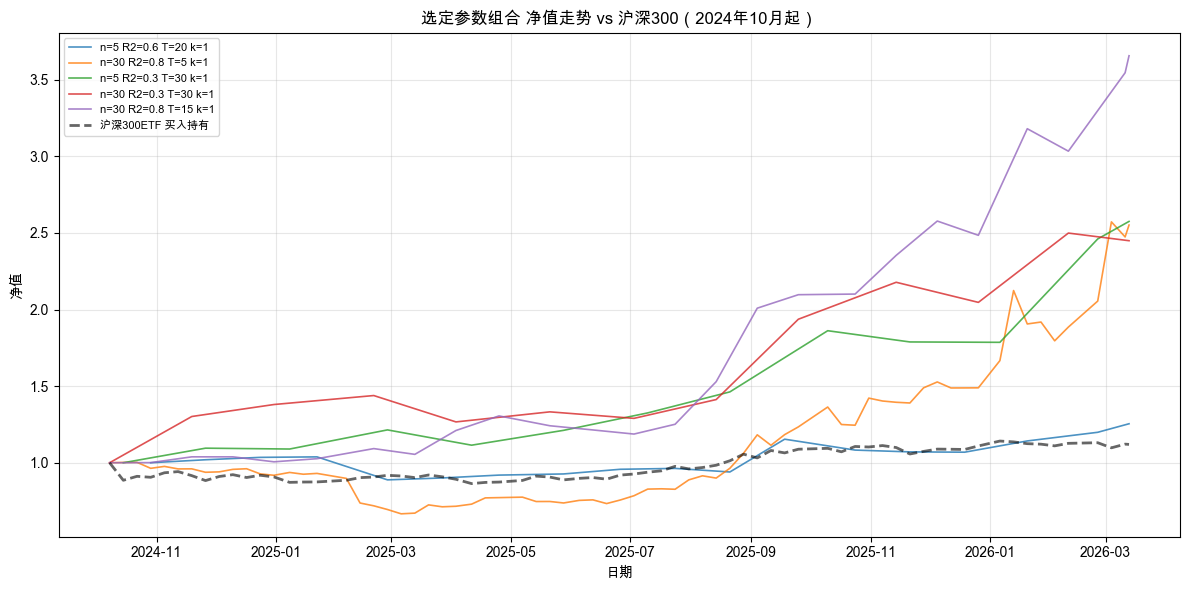

In [11]:
from datetime import datetime
from pathlib import Path

nav_dict = {}
for i, row in params.iterrows():
    n = int(row['n'])
    r2_th = float(row['R2_threshold'])
    rebal = int(row['rebal_period'])
    topk = int(row['top_k'])
    idx = i + 1  # 序号，与图例、标的一致
    label = f'{idx}. n={n} R2={r2_th} T={rebal} k={topk}'
    trade_df = engine.back_history(n=n, r2_threshold=r2_th, rebal_period=rebal, top_k=topk)
    nav_dict[label] = pd.Series(
        trade_df['总净值'].values,
        index=pd.to_datetime(trade_df['结束日期']),
    )
    # 2024-10 起的数据另存为 history_202410_{参数}.csv，与全量 history_{参数}.csv 区分
    out_dir = Path('history') / datetime.now().strftime('%Y%m%d')
    out_dir.mkdir(parents=True, exist_ok=True)
    trade_202410 = trade_df[pd.to_datetime(trade_df['结束日期']) >= '2024-10-01']
    if not trade_202410.empty:
        trade_202410.to_csv(out_dir / f'history_202410_{n}_{r2_th}_{rebal}_{topk}.csv', index=False, encoding='utf-8-sig')

# 第3节：仅从 2024年10月 开始画
start_202410 = pd.Timestamp('2024-10-01')
nav_plot = {k: s[s.index >= start_202410] for k, s in nav_dict.items() if (s.index >= start_202410).any()}
for k in nav_plot:
    nav_plot[k] = nav_plot[k] / nav_plot[k].iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
for label, nav_series in nav_plot.items():
    ax.plot(nav_series.index, nav_series.values, label=label, linewidth=1.2, alpha=0.8)

bench_sym = 'SH510300'
all_dates = sorted(set().union(*(s.index for s in nav_plot.values())))
if bench_sym in engine._panel.columns:
    bench = engine._panel[bench_sym].reindex(all_dates, method='ffill')
    bench_nav = bench / bench.iloc[0]
    ax.plot(bench_nav.index, bench_nav.values, label='沪深300ETF 买入持有',
            linewidth=2, color='black', linestyle='--', alpha=0.6)

ax.set_ylabel('净值')
ax.set_xlabel('日期')
ax.set_title('选定参数组合 净值走势 vs 沪深300（2024年10月起）')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 自 2014 年以来走势（一张图）

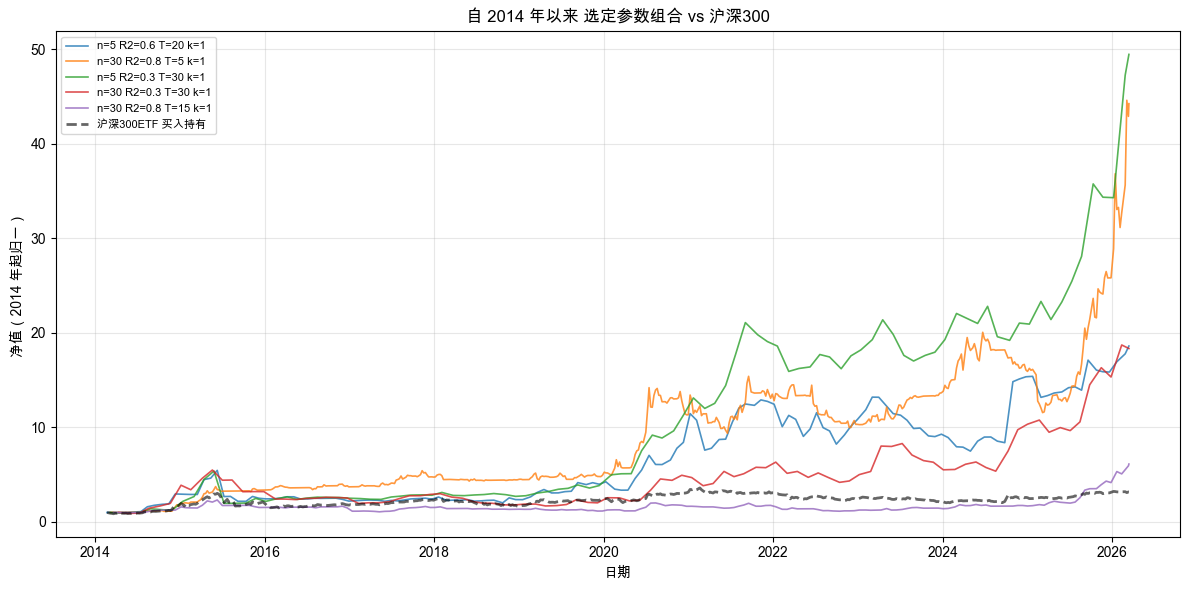

In [9]:
start_2014 = pd.Timestamp('2014-01-01')
nav_dict_2014 = {k: s[s.index >= start_2014] for k, s in nav_dict.items() if (s.index >= start_2014).any()}
for k in nav_dict_2014:
    nav_dict_2014[k] = nav_dict_2014[k] / nav_dict_2014[k].iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
for label, nav_series in nav_dict_2014.items():
    ax.plot(nav_series.index, nav_series.values, label=label, linewidth=1.2, alpha=0.8)

all_dates_2014 = sorted(set().union(*(s.index for s in nav_dict_2014.values())))
if bench_sym in engine._panel.columns and all_dates_2014:
    bench_2014 = engine._panel[bench_sym].reindex(all_dates_2014, method='ffill').dropna()
    if not bench_2014.empty:
        bench_2014 = bench_2014 / bench_2014.iloc[0]
        ax.plot(bench_2014.index, bench_2014.values, label='沪深300ETF 买入持有',
                linewidth=2, color='black', linestyle='--', alpha=0.6)

ax.set_ylabel('净值（2014 年起归一）')
ax.set_xlabel('日期')
ax.set_title('自 2014 年以来 选定参数组合 vs 沪深300')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 各参数组合下一期标的

In [10]:
print('各参数组合 下一期标的（基于最新交易日）\n')
for i, row in params.iterrows():
    n = int(row['n'])
    r2_th = float(row['R2_threshold'])
    rebal = int(row['rebal_period'])
    topk = int(row['top_k'])
    idx = i + 1  # 序号，与图例一致
    label = f'n={n} R2={r2_th} T={rebal} k={topk}'
    sig = engine.next(n=n, r2_threshold=r2_th, top_k=topk)
    print(f'【{idx}】{label}')
    print(f'  日期: {sig["date"]}  操作: {sig["action"]}')
    if sig['holdings']:
        for h in sig['holdings']:
            print(f'    {h["symbol"]} {h["name"]}  斜率={h["slope"]:.6f}  R²={h["r2"]:.4f}  价格={h["price"]:.4f}')
    else:
        print('    空仓')
    print()

各参数组合 下一期标的（基于最新交易日）

【n=5 R2=0.6 T=20 k=1】
  日期: 2026-03-13  操作: buy
    SH515220 煤炭ETF  斜率=0.017506  R²=0.6191  价格=1.3390

【n=30 R2=0.8 T=5 k=1】
  日期: 2026-03-13  操作: buy
    SZ159326 电网设备ETF  斜率=0.007500  R²=0.8681  价格=2.0600

【n=5 R2=0.3 T=30 k=1】
  日期: 2026-03-13  操作: buy
    SH515220 煤炭ETF  斜率=0.017506  R²=0.6191  价格=1.3390

【n=30 R2=0.3 T=30 k=1】
  日期: 2026-03-13  操作: buy
    SZ159309 油气ETF汇添富  斜率=0.010028  R²=0.7391  价格=1.6200

【n=30 R2=0.8 T=15 k=1】
  日期: 2026-03-13  操作: buy
    SZ159326 电网设备ETF  斜率=0.007500  R²=0.8681  价格=2.0600

